In [1]:
import os
import torch

from sensorium.utility import get_data, set_random_seed
from sensorium.models import stacked_core_full_gauss_readout, stacked_core_factorized_readout

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

if False:
    more_basepath = "/user/turishcheva/more_data_like_sensorium_2022"
    for file in [
        "static20457-5-9-94c6ff995dac583098847cfecd43e7b6",
        "static20622-2-14-94c6ff995dac583098847cfecd43e7b6",
        "static20892-10-10-94c6ff995dac583098847cfecd43e7b6",
        "static22223-2-15-94c6ff995dac583098847cfecd43e7b6",
        "static22564-2-12-94c6ff995dac583098847cfecd43e7b6",
        "static22620-4-15-94c6ff995dac583098847cfecd43e7b6",
        "static23555-5-12-94c6ff995dac583098847cfecd43e7b6",
    ]:
        filenames.append(os.path.join(more_basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

fact_config = {
    'hidden_channels': 96, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'hidden_padding': None, 
    'stack': -1,
    'layers': 4,
    'input_kern': 9, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 1.0, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    
    'shifter': True,
    'shifter_bias': False,
    'hidden_channels_shifter': 5,
    'shift_layers': 1,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': 'adaptive_log_norm',
    'gamma_sigma': 0.25,
    #'readout_type': args.readout_type,
    # 'discretized_spatial': args.discretized,
    # 'kernel_size': args.kernel_size,
    # 'sigma': args.sigma,
    'init_gain': 0.1,
    'whitener': True,
    'whitener_momentum': 0.003,
}

import copy
gauss_config = copy.deepcopy(fact_config)
gauss_config['grid_mean_predictor'] = {
    'type': 'cortex',
    'input_dimensions': 2,
    'hidden_layers': 0,
    'hidden_features': 30,
    'final_tanh': True
}
gauss_config['init_sigma'] = 0.1
gauss_config['init_mu_range'] = 0.3
gauss_config['gauss_type'] = 'full'

In [ ]:
gauss_paths = [
    '../training/runs/gaussian_seed0/model_weights.pth',
    '../training/runs/gaussian_seed42/model_weights.pth',
    '../training/runs/gaussian_seed123/model_weights.pth',
]
fact_paths = [
    '../training/runs/factorized_seed0/model_weights.pth',
    '../training/runs/factorized_seed42/model_weights.pth',
    '../training/runs/factorized_seed123/model_weights.pth',
]

In [12]:
gauss_readouts = []
for path in gauss_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **gauss_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval();
    
    r = torch.cat([model.readout[key].features.detach().squeeze().T for key in data_keys])
    r = model.whitener.transform_weights(r.T).T.cpu()
    gauss_readouts.append(r)

gauss_curve, k_range = get_knn_curve(gauss_readouts)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [3]:
fact_readouts = []
for path in fact_paths:
    model = stacked_core_factorized_readout(dataloaders, random_seed, **fact_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval();
    
    r = torch.cat([model.readout[key].features.detach() for key in data_keys])
    r = model.whitener.transform_weights(r.T).T.cpu()
    fact_readouts.append(r)

fact_curve, k_range = get_knn_curve(fact_readouts)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


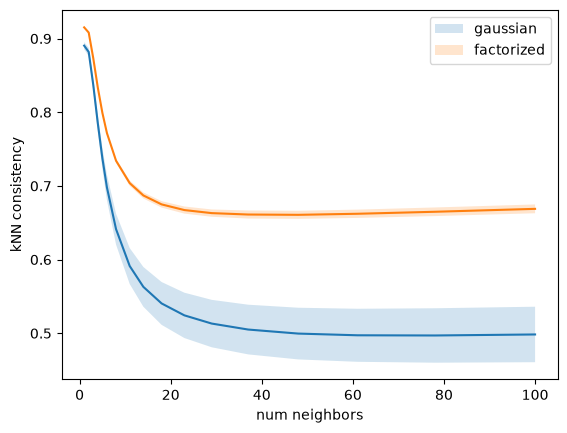

In [13]:
# Get the default color cycle
# colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# for curve, label, color in zip(
#     [factorized_curve_old, factorized_curve], 
#     ['normal shifter', 'retinotopy shifter'],
#     colors[1:7]
# ):
m, s = gauss_curve[0], gauss_curve[1]
plt.plot(k_range, m)
plt.fill_between(k_range, m - s, m + s, alpha=0.2, label='gaussian')

m, s = fact_curve[0], fact_curve[1]
plt.plot(k_range, m)
plt.fill_between(k_range, m - s, m + s, alpha=0.2, label='factorized')

plt.xlabel('num neighbors')
plt.ylabel('kNN consistency')
plt.legend()
plt.show()